In [109]:
import pandas as pd
import monai
import os
import nibabel as nib
from tqdm import tqdm

In [111]:
data = pd.read_csv("/home/jaalzate/Radiomics-Prostate-Cancer/artifacts/bimcv_data/BIMCV_with_predictions.csv")

#Fix paths
data['image_t2'] = data['image_t2'].str.replace("prueba/","")
data['image_adc'] = data['image_adc'].str.replace("prueba/","")
data['image_dwi'] = data['image_dwi'].str.replace("prueba/","")

data['image_t2'] = data['image_t2'].apply(lambda x: x.replace("_reborn","") if "p0052021" in x else x)
data['image_adc'] = data['image_adc'].apply(lambda x: x.replace("_reborn","") if "p0052021" in x else x)
data['image_dwi'] = data['image_dwi'].apply(lambda x: x.replace("_reborn","") if "p0052021" in x else x)

In [112]:
import os
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# enable tqdm on pandas
tqdm.pandas()

def make_seg_path(t2_path: str) -> str:
    """
    Given a T2w image path, build the corresponding SEG path.
    """
    p = Path(t2_path)
    # reconstruct the first 6 parts + derivatives directory + remaining parts
    base = Path(*p.parts[:6]) / 'derivatives' / 'prostate_segmentation'
    rest = Path(*p.parts[6:-1])
    seg_fname = p.name.replace('T2w', 'mod-T2w_desc-SEG')
    return str(base / rest / seg_fname)

def compute_volume_ml(seg_path: str) -> float:
    """
    Load a segmentation NIfTI, count non-zero voxels, 
    and return volume in mL. Returns np.nan if file not found.
    """
    if not os.path.exists(seg_path):
        return np.nan

    img = nib.load(seg_path)
    arr = img.get_fdata()
    vx, vy, vz = img.header.get_zooms()
    voxel_vol = vx * vy * vz           # mm³
    count = np.count_nonzero(arr > 0)
    return (count * voxel_vol) / 1000  # convert to mL


# 1. Build the seg-path column
data['prostate_segmentation'] = data['image_t2'].progress_apply(make_seg_path)

# 2. Compute volumes in mL (NaN if missing)
data['VP_segmentation'] = data['prostate_segmentation'].progress_apply(compute_volume_ml)

# Optional: report how many failed
n_missing = data['VP_segmentation'].isna().sum()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4663/4663 [05:02<00:00, 15.42it/s]


In [200]:
data[(data['VP_segmentation']<15) & (data['VP_segmentation']>10)]

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,...,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,prediction,probability,prostate_segmentation
28,sub-005585,ses-006039,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,5.0,81.0,NaN,NaN,NaN,...,2.0,0.0,1932-12-14,2014-09-14,train,False,14.588186,0.0,0.893059,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
53,sub-008110,ses-009013,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,78.0,NaN,NaN,NaN,...,NaN,1.0,1932-11-19,2011-04-25,train,False,12.494867,1.0,0.985280,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
54,sub-008110,ses-009013,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,78.0,NaN,NaN,NaN,...,NaN,1.0,1932-11-19,2011-04-25,train,False,13.049072,1.0,0.986711,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
55,sub-008110,ses-009013,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,78.0,NaN,NaN,NaN,...,NaN,1.0,1932-11-19,2011-04-25,train,False,12.597106,1.0,0.986704,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
74,sub-008269,ses-009205,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,5.0,72.0,NaN,NaN,NaN,...,4.0,0.0,1944-01-06,2016-04-13,train,False,10.165935,0.0,0.736801,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4321,sub-006586,ses-007176,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,21.0,67.0,NaN,NaN,NaN,...,NaN,1.0,1941-09-21,2009-06-23,train,False,10.695283,1.0,0.992111,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
4356,sub-001231,ses-001329,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,21.0,79.0,NaN,NaN,NaN,...,NaN,1.0,1934-12-12,2014-01-23,train,False,10.866770,1.0,0.946271,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
4373,sub-001233,ses-008063,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,21.0,77.0,NaN,NaN,NaN,...,NaN,1.0,1931-06-26,2009-05-09,train,False,12.938210,1.0,0.990824,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
4391,sub-001265,ses-001363,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,66.0,NaN,1.0,NaN,...,NaN,1.0,1944-07-15,2011-10-25,train,False,10.462450,1.0,0.991959,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...


In [138]:
n_missing

240

In [210]:
# Compute IQR
Q1 = data["VP_segmentation"].quantile(0.25)
Q3 = data["VP_segmentation"].quantile(0.9)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = 19#Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter non-outliers
filtered_data = data[(data["VP_segmentation"] >= lower_bound) & (data["VP_segmentation"] <= upper_bound)]

print(filtered_data.describe())

               dep           ED    AF           TB         TR          PSA  \
count  3465.000000  3465.000000  49.0  1664.000000  11.000000  3197.000000   
mean     12.135931    67.286869  11.0     1.701923   0.727273    10.936732   
std       5.917421     7.658805   0.0     0.931236   0.467099    21.537761   
min       3.000000    36.000000  11.0     1.000000   0.000000     0.014000   
25%       7.000000    62.000000  11.0     1.000000   0.500000     5.510000   
50%      17.000000    68.000000  11.0     1.000000   1.000000     7.520000   
75%      17.000000    73.000000  11.0     2.000000   1.000000    11.500000   
max      21.000000    96.000000  11.0     6.000000   1.000000   982.000000   

                  VP          PIR         csPC  VP_segmentation   prediction  \
count    2461.000000  1383.000000  3465.000000      3465.000000  3465.000000   
mean      354.933870     3.819234     0.503608        53.106033     0.498990   
std      5298.689372     1.165349     0.500059        30.

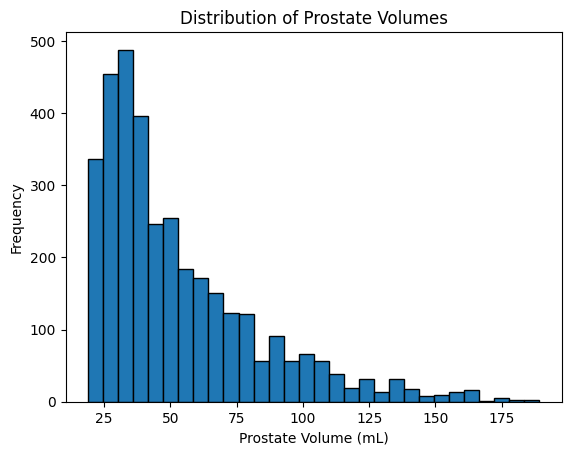

In [212]:
import matplotlib.pyplot as plt

plt.hist(filtered_data["VP_segmentation"], bins=30, edgecolor="black")
plt.xlabel("Prostate Volume (mL)")
plt.ylabel("Frequency")
plt.title("Distribution of Prostate Volumes")
plt.show()

In [213]:
filtered_data

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,...,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,prediction,probability,prostate_segmentation
0,sub-002299,ses-002477,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,82.0,NaN,2.0,NaN,...,NaN,1.0,1935-05-07,2013-05-25,train,False,79.406843,1.0,0.992130,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
1,sub-002299,ses-002477,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,82.0,NaN,2.0,NaN,...,NaN,1.0,1935-05-07,2013-05-25,train,False,78.215001,0.0,0.688936,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
2,sub-002299,ses-002477,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,82.0,NaN,2.0,NaN,...,NaN,1.0,1935-05-07,2013-05-25,train,False,78.989191,1.0,0.992248,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
3,sub-002299,ses-004352,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,82.0,NaN,2.0,NaN,...,NaN,1.0,1935-05-07,2014-12-25,train,False,44.065087,1.0,0.995353,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
4,sub-002299,ses-004352,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,82.0,NaN,2.0,NaN,...,NaN,1.0,1935-05-07,2014-12-25,train,False,43.964298,1.0,0.995131,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4441,sub-001267,ses-001365,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,68.0,NaN,1.0,NaN,...,NaN,1.0,1937-12-13,2006-08-27,train,False,34.082813,1.0,0.956273,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
4442,sub-001267,ses-001365,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,68.0,NaN,1.0,NaN,...,NaN,1.0,1937-12-13,2006-08-27,train,False,36.461134,1.0,0.994162,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
4443,sub-001267,ses-001365,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,68.0,NaN,1.0,NaN,...,NaN,1.0,1937-12-13,2006-08-27,train,False,36.682389,1.0,0.993178,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...
4444,sub-001034,ses-001123,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,/mnt/ceib/datalake/FISABIO_datalake/p0052021/s...,17.0,68.0,11.0,1.0,NaN,...,NaN,0.0,1945-04-19,2014-01-02,train,False,35.087653,0.0,0.867609,/mnt/ceib/datalake/FISABIO_datalake/p0052021/d...


In [217]:
filtered_data.to_csv("/home/jaalzate/Radiomics-Prostate-Cancer/artifacts/bimcv_data/BIMCV_with_predictions_filtered_volume.csv")

In [214]:
idx = 4441
img_path = data['image_t2'][idx]
seg_path = data['prostate_segmentation'][idx]

In [215]:
img = monai.transforms.LoadImage(image_only=True, ensure_channel_first=True)(img_path)
seg = monai.transforms.LoadImage(image_only=True, ensure_channel_first=True)(seg_path)

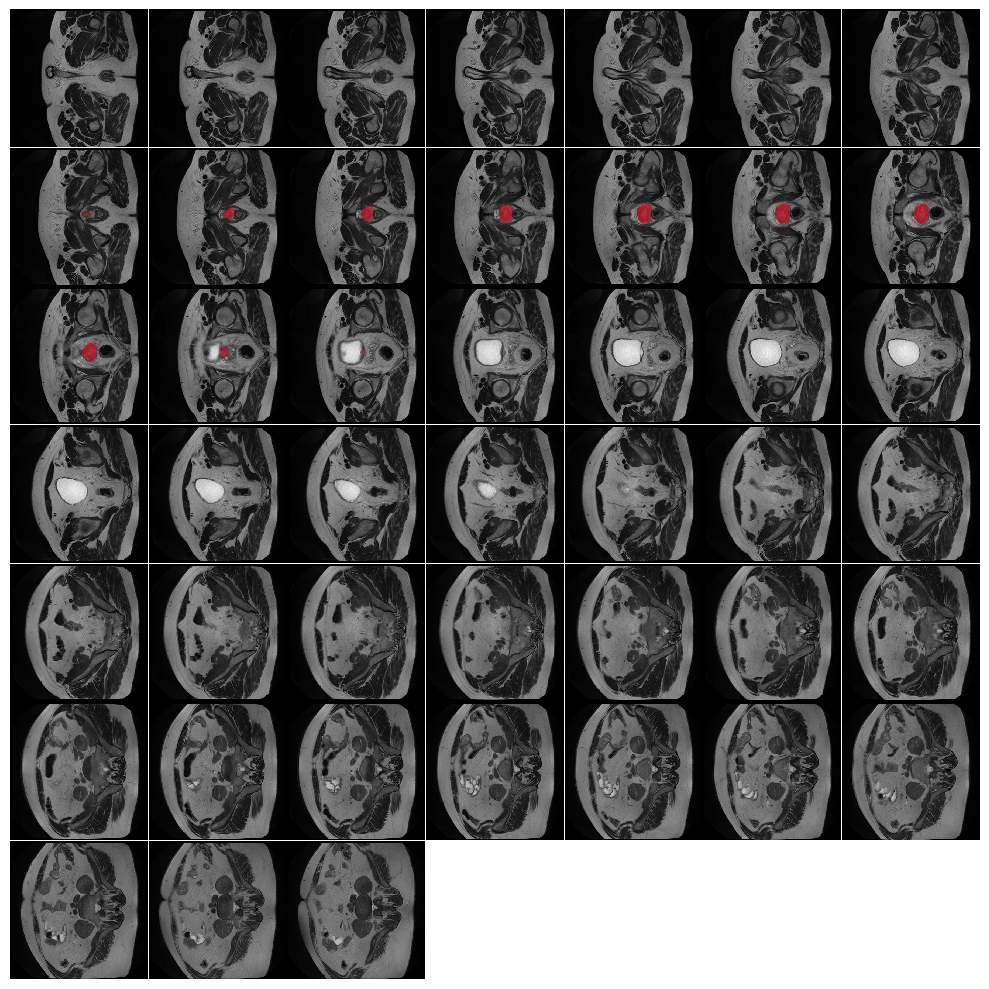

(<Figure size 1000x1000 with 1 Axes>,
 array([[[nan, nan, nan],
         [nan, nan, nan],
         [nan, nan, nan],
         ...,
         [nan, nan, nan],
         [nan, nan, nan],
         [nan, nan, nan]],
 
        [[nan, nan, nan],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         [nan, nan, nan]],
 
        [[nan, nan, nan],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         [nan, nan, nan]],
 
        ...,
 
        [[nan, nan, nan],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         ...,
         [nan, nan, nan],
         [nan, nan, nan],
         [nan, nan, nan]],
 
        [[nan, nan, nan],
         [ 0.,  0.,  0.],
         [ 0.,  0.,  0.],
         ...,
         [nan, nan, nan],
         [nan, nan, nan],
         [nan, nan, nan]],
 
        [[nan, nan, nan],
         [nan, nan, nan],
         [nan, nan, nan],
    

In [216]:
blend = monai.visualize.blend_images(img,seg)
monai.visualize.matshow3d(blend,channel_dim=0,frame_dim=-1,show=True,cmap='gray')